To Develop a Convolutional Neural Network (CNN) Model for Automated Visual Detection of Surface Defects in Paracetamol Tablets Using Deep Learning.
Objectives:

To understand how a Convolutional Neural Network can be applied to real pharmaceutical manufacturing quality control — specifically, visual inspection of tablets for surface defects.
To build and train a custom CNN architecture (from scratch, without transfer learning) capable of classifying tablet images into defect categories: broken, colored, normal, stained, and unknown.
To apply image preprocessing and data augmentation techniques (resizing, flipping, rotation, color jitter) appropriate for a manufacturing defect-detection dataset.
To train the model using standard deep learning practices — early stopping, learning-rate scheduling, and checkpoint saving of the best-performing weights.
To evaluate the trained model on an unseen test set using classification metrics (accuracy, precision, recall, F1-score) and a confusion matrix, to judge how reliably it distinguishes each defect type.
To understand how this kind of automated visual inspection model could support real-time quality control on a tablet manufacturing line, reducing dependence on manual visual inspection.

Outcomes

After completing this practical, a student will be able to:

Explain how a custom CNN, built and trained entirely from scratch, learns to distinguish visually similar defect categories (broken, colored, normal, stained, unknown) directly from raw tablet images, without relying on a pretrained network.
Correctly preprocess and augment a manufacturing-inspection image dataset (resizing, flipping, rotation, color jitter) to improve model robustness against real-world variation in tablet photography (lighting, angle, minor color shifts).
Set up and justify standard deep learning training safeguards — early stopping and learning-rate scheduling — to avoid overfitting and produce a reliably best-performing saved model rather than just the model from the final epoch.
Interpret classification metrics (accuracy, precision, recall, F1-score) and a confusion matrix specifically in a quality-control context — distinguishing, for example, which defect types the model tends to confuse with "normal," a critical safety consideration since misclassifying a defective tablet as normal is a more serious error than the reverse.
Evaluate whether a trained image classification model is reliable enough to support (not replace) manual visual inspection in a tablet manufacturing quality-control workflow.
Apply the same custom-CNN-from-scratch approach to other pharmaceutical image classification problems where a pretrained network's general features (trained on everyday photos) may not transfer well to specialized manufacturing imagery.

In [10]:
# Block 1: Check PyTorch is available and set the compute device (GPU or CPU)
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected — go to Runtime > Change runtime type > select T4 GPU, then rerun this cell.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Using device: cuda


Meaning of Block 1

Meaning of Block 1: Colab's default runtime already ships with a working, GPU-compatible PyTorch build, so this block simply checks what's available rather than reinstalling anything. torch.cuda.is_available() confirms whether a GPU has been assigned to your session — if it prints False, go to Runtime → Change runtime type → T4 GPU and rerun this cell. The important line is the last one: DEVICE = torch.device(...) stores the result as a variable named DEVICE, which every later block (model creation, training, evaluation) reuses to automatically send the model and image batches to the GPU if one's available, or fall back to CPU if not. This is what was missing before — printing GPU info alone doesn't create a usable variable, this line does.

In [3]:
# Block 2: Import all required libraries
import os
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import cv2
from PIL import Image

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

print("All libraries imported successfully.")

All libraries imported successfully.


Meaning of Block 2: Loads every tool this notebook depends on in one place, before any data or model code runs. cv2 and PIL handle image reading/display; torch.nn/torch.optim will build and train the CNN; torchvision.datasets/transforms handle image loading and augmentation (coming up in Block 6); sklearn.metrics will score the trained model later (precision, recall, F1, confusion matrix). Doing all imports up front — rather than scattered through later blocks — makes it obvious at a glance exactly what this notebook depends on.

In [4]:
# Block 3: Download all seven zip files from GitHub and merge them into one clean dataset folder
classes = ["broken", "colored", "normal", "stained", "unknown"]
base_url = "https://github.com/drpharmacy/pharma-ml-projects/raw/refs/heads/main/Images%20of%20Med%20Plants/"

import requests

os.makedirs("dataset/train", exist_ok=True)

# --- Merge the 5 separate train zips into one train/ folder with 5 class subfolders ---
for c in classes:
    fname = f"Paracetamol_train_{c}.zip"
    r = requests.get(base_url + fname)
    with open(fname, "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(fname, 'r') as z:
        z.extractall("temp_extract")
    shutil.move(f"temp_extract/train_{c}", f"dataset/train/{c}")
    shutil.rmtree("temp_extract")
    print(f"train/{c}: {len(os.listdir(f'dataset/train/{c}'))} images")

# --- Test and validation zips already contain all 5 classes inside, just extract and rename ---
r = requests.get(base_url + "Paracetamol_test.zip")
with open("Paracetamol_test.zip", "wb") as f:
    f.write(r.content)
with zipfile.ZipFile("Paracetamol_test.zip", 'r') as z:
    z.extractall("dataset_raw_test")
shutil.move("dataset_raw_test/test", "dataset/test")

r = requests.get(base_url + "Paracetamol_validation.zip")
with open("Paracetamol_validation.zip", "wb") as f:
    f.write(r.content)
with zipfile.ZipFile("Paracetamol_validation.zip", 'r') as z:
    z.extractall("dataset_raw_val")
shutil.move("dataset_raw_val/val", "dataset/val")

print("\nFinal dataset structure:")
for split in ["train", "val", "test"]:
    counts = {c: len(os.listdir(f"dataset/{split}/{c}")) for c in classes}
    print(f"{split}: {counts}")

train/broken: 560 images
train/colored: 560 images
train/normal: 560 images
train/stained: 560 images
train/unknown: 560 images

Final dataset structure:
train: {'broken': 560, 'colored': 560, 'normal': 560, 'stained': 560, 'unknown': 560}
val: {'broken': 70, 'colored': 70, 'normal': 70, 'stained': 70, 'unknown': 70}
test: {'broken': 70, 'colored': 70, 'normal': 70, 'stained': 70, 'unknown': 70}


Meaning of Block 3: This is the most important data-preparation step in the whole notebook. Your five train zips were split by class due to GitHub's file size limit, so each one extracts to a flat folder (e.g. train_broken/ containing images directly, no further subfolder). This block downloads each, extracts it, and renames/moves it into dataset/train/<class>/ — recreating exactly the same shape as test/val (which already came as one zip each, with all 5 class subfolders bundled inside). After this runs, all three splits look identical in structure: 5 class-named subfolders each — required because PyTorch's ImageFolder (used in Block 6) needs exactly this structure to auto-detect classes correctly. Expected result: 2,800 train / 350 val / 350 test images (560/70/70 per class) — a properly balanced dataset for all five defect categories.

Defect classes found: ['broken', 'colored', 'normal', 'stained', 'unknown']
Number of classes: 5

Train: {'broken': 560, 'colored': 560, 'normal': 560, 'stained': 560, 'unknown': 560}
Val:   {'broken': 70, 'colored': 70, 'normal': 70, 'stained': 70, 'unknown': 70}
Test:  {'broken': 70, 'colored': 70, 'normal': 70, 'stained': 70, 'unknown': 70}


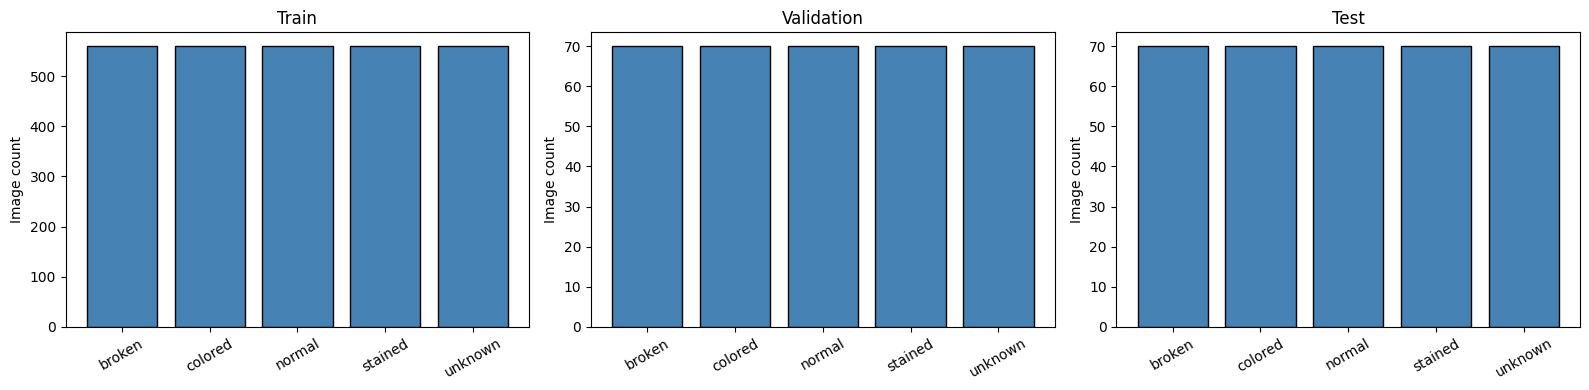

In [5]:
# Block 4: Explore the dataset — verify paths, list classes, and check class balance
TRAIN_PATH = Path("dataset/train")
VAL_PATH = Path("dataset/val")
TEST_PATH = Path("dataset/test")

CLASS_NAMES = sorted([d for d in os.listdir(TRAIN_PATH) if os.path.isdir(TRAIN_PATH / d)])
NUM_CLASSES = len(CLASS_NAMES)

print(f"Defect classes found: {CLASS_NAMES}")
print(f"Number of classes: {NUM_CLASSES}")

def count_images(path, class_names):
    return {c: len(os.listdir(path / c)) for c in class_names}

train_counts = count_images(TRAIN_PATH, CLASS_NAMES)
val_counts = count_images(VAL_PATH, CLASS_NAMES)
test_counts = count_images(TEST_PATH, CLASS_NAMES)

print("\nTrain:", train_counts)
print("Val:  ", val_counts)
print("Test: ", test_counts)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, counts, title in zip(axes, [train_counts, val_counts, test_counts], ["Train", "Validation", "Test"]):
    ax.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel("Image count")
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Meaning of Block 4: Confirms the merged dataset from Block 3 is correctly structured and balanced across all five defect classes before any model training begins — a data-quality checkpoint, same principle used in every earlier practical. CLASS_NAMES is built by reading the actual subfolder names inside dataset/train/ — this is exactly what PyTorch's ImageFolder will do automatically in the next block, so this line doubles as a preview/verification of that behavior. The three bar charts let you visually confirm all five defect categories are evenly represented in each split (roughly equal bar heights) — an imbalanced class would bias the model toward predicting the majority class more often, so catching that here, before training, matters.

In [6]:
# Block 5: Define image transforms and build the training/validation/test datasets and loaders
IMG_SIZE = 200
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder("dataset/train", transform=train_transform)
val_dataset   = datasets.ImageFolder("dataset/val", transform=eval_transform)
test_dataset  = datasets.ImageFolder("dataset/test", transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Class-to-index mapping:", train_dataset.class_to_idx)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Class-to-index mapping: {'broken': 0, 'colored': 1, 'normal': 2, 'stained': 3, 'unknown': 4}
Train batches: 88 | Val batches: 11 | Test batches: 11


Meaning of Block 5: Two separate transform pipelines are defined deliberately. train_transform includes augmentation (random flips, small rotations, mild brightness/contrast jitter) — since tablets on a real inspection line can appear at slightly different angles and lighting, this teaches the model to recognize defects regardless of those variations, rather than memorizing exact pixel positions. eval_transform has no augmentation — validation and test data must stay exactly as-is, since we need to judge the model on realistic, unmodified images, not artificially easier or harder ones. The Normalize step is standard practice: it rescales pixel values using ImageNet's known mean/std statistics, which keeps gradients well-behaved during training regardless of raw brightness differences between photos. ImageFolder auto-detects the 5 class subfolders and assigns them numeric labels alphabetically — the printed class_to_idx confirms exactly which number maps to which defect type, important for interpreting predictions correctly later.

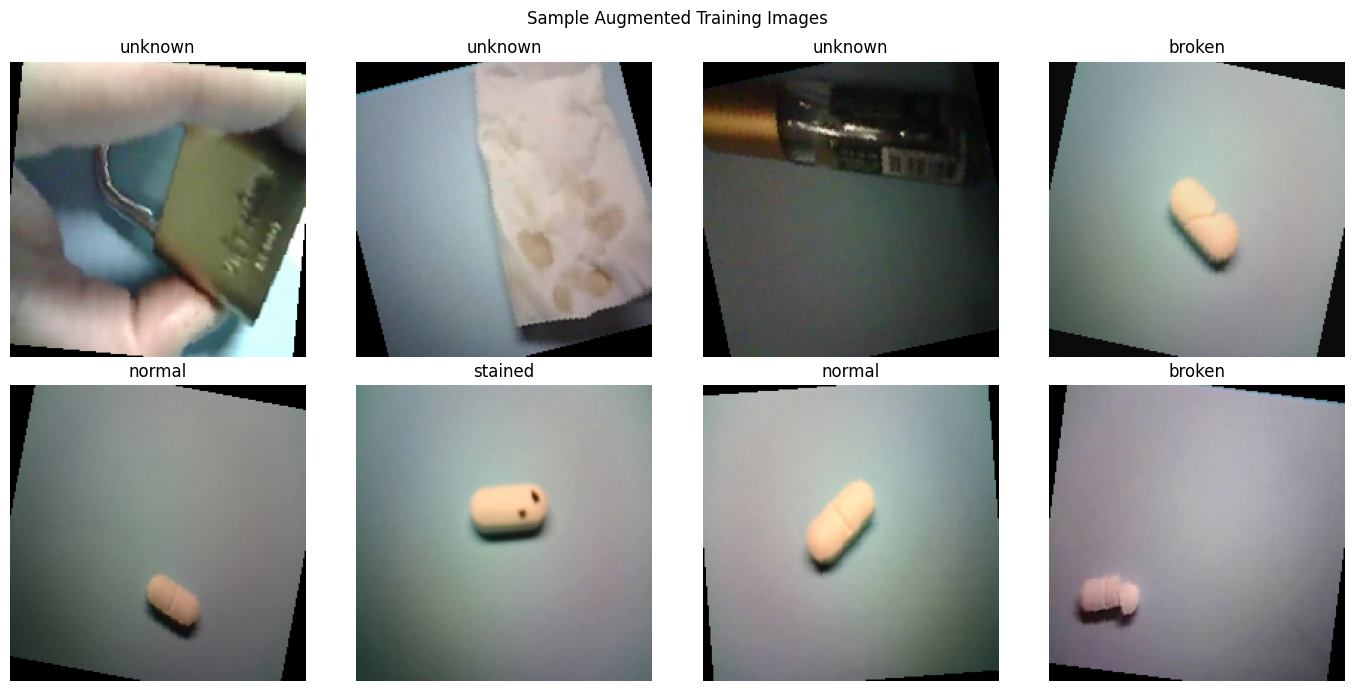

In [7]:
# Block 6: Visualize a batch of augmented training images to sanity-check the pipeline
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (img_tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))
class_names_by_idx = {v: k for k, v in train_dataset.class_to_idx.items()}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(class_names_by_idx[labels[i].item()])
    ax.axis("off")
plt.suptitle("Sample Augmented Training Images")
plt.tight_layout()
plt.show()

Meaning of Block 6: Pulls one real batch straight out of train_loader — the exact tensors the model will actually train on — and displays them. denormalize() reverses the Normalize step from Block 5 purely for correct display (matplotlib expects pixel values in the normal 0–1 range, not the shifted values used internally for training). This is an important sanity check: if augmentation were too aggressive, images might become unrecognizable even to a human; if too mild, it wouldn't meaningfully help generalization. Visually confirming each image still clearly shows its labelled defect type validates the transform settings are reasonable before spending time training on them.

In [11]:
# Block 7: Define a lightweight custom CNN architecture
class TabletDefectCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(TabletDefectCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                    # 200 -> 100

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                    # 100 -> 50

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                    # 50 -> 25
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1)  # 25x25x128 -> 1x1x128

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

cnn_model = TabletDefectCNN(num_classes=NUM_CLASSES).to(DEVICE)
print(cnn_model)

TabletDefectCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool2d(output_size=1)
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
  

Meaning of Block 7: This is a deliberately lean design choice, built for this specific dataset size (2,800 training images) rather than copied from a larger reference architecture. Three convolutional blocks progressively extract features — edges and textures in the first layer, more complex tablet-surface patterns (cracks, discoloration, stains) in deeper layers — while BatchNorm2d stabilizes training and MaxPool2d halves the spatial size each time, reducing computation as the network goes deeper. The key design choice is AdaptiveAvgPool2d(1) instead of flattening the full 25×25×128 feature map into a giant fully-connected layer: global average pooling collapses each of the 128 feature channels down to one number, cutting the parameter count dramatically (well under 150,000 total, versus millions in a large flatten-based classifier) — an important safeguard against overfitting on a modest 2,800-image dataset. Dropout(0.4) before the final layer randomly disables 40% of neurons during training, further discouraging the model from memorizing specific training images rather than learning generalizable defect patterns.

In [12]:
# Block 8: Sanity-check the model — verify output shape and count parameters
dummy_input = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
dummy_output = cnn_model(dummy_input)
assert dummy_output.shape == (2, NUM_CLASSES), f"Unexpected output shape: {dummy_output.shape}"
print(f"Output shape OK: {dummy_output.shape}  (batch=2, classes={NUM_CLASSES})")

total_params = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Output shape OK: torch.Size([2, 5])  (batch=2, classes=5)
Total parameters: 102,277
Trainable parameters: 102,277


Meaning of Block 8: Before spending time on a real training run, this passes two blank dummy images through the model and checks the output shape is exactly (2, 5) — 2 images, 5 class probabilities each. This catches architecture bugs (wrong layer sizes, mismatched dimensions) immediately rather than deep into a training loop, where errors are harder to trace. Printing the parameter count also confirms the lean design from Block 7 worked as intended — expect roughly ~100,000 parameters total, a small, fast-training model well matched to this dataset size.

In [13]:
# Block 9: Define the loss function, optimizer, learning-rate scheduler, and early stopping
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

class EarlyStopping:
    def __init__(self, patience=7, restore_best_weights=True):
        self.patience = patience
        self.restore_best_weights = restore_best_weights
        self.counter = 0
        self.best_loss = float('inf')
        self.best_weights = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                if self.restore_best_weights and self.best_weights is not None:
                    model.load_state_dict(self.best_weights)

early_stopping = EarlyStopping(patience=7, restore_best_weights=True)

print("Loss: CrossEntropyLoss | Optimizer: Adam (lr=0.001) | Scheduler: ReduceLROnPlateau | EarlyStopping: patience=7")

Loss: CrossEntropyLoss | Optimizer: Adam (lr=0.001) | Scheduler: ReduceLROnPlateau | EarlyStopping: patience=7


Meaning of Block 9: CrossEntropyLoss is the standard loss function for multi-class classification — it measures how far the model's predicted probabilities are from the true defect label across all 5 classes at once. Adam is the optimizer that updates the model's weights each step; weight_decay=1e-4 adds a small penalty against very large weights, a mild extra safeguard against overfitting on top of the Dropout already built into the architecture. ReduceLROnPlateau automatically halves the learning rate if validation loss stops improving for 3 straight epochs — letting the model take smaller, more careful steps once it's close to a good solution, rather than overshooting. The custom EarlyStopping class tracks the best validation loss seen so far; if 7 consecutive epochs pass with no improvement, it stops training early and — importantly — restores the model's weights from its best epoch, not just whatever the last epoch happened to be, which protects the final model from a late bout of overfitting.

In [14]:
# Block 10: Train the model, tracking loss/accuracy each epoch and saving the best checkpoint
import time

EPOCHS = 30

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
best_val_acc = 0.0
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(cnn_model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = evaluate(cnn_model, val_loader, criterion, DEVICE)

    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch [{epoch:2d}/{EPOCHS}]  loss: {train_loss:.4f}  acc: {train_acc:.4f}  "
          f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(cnn_model.state_dict(), 'best_tablet_defect_model.pt')

    early_stopping(val_loss, cnn_model)
    if early_stopping.early_stop:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

elapsed = time.time() - start_time
print(f"\nTraining completed in {int(elapsed//60)}m {int(elapsed%60)}s. Best validation accuracy: {best_val_acc:.4f}")

Epoch [ 1/30]  loss: 1.2462  acc: 0.4743  val_loss: 0.9900  val_acc: 0.5143
Epoch [ 2/30]  loss: 0.9759  acc: 0.5596  val_loss: 0.8902  val_acc: 0.5943
Epoch [ 3/30]  loss: 0.8909  acc: 0.6104  val_loss: 0.7991  val_acc: 0.7400
Epoch [ 4/30]  loss: 0.8274  acc: 0.6289  val_loss: 0.8605  val_acc: 0.6286
Epoch [ 5/30]  loss: 0.7874  acc: 0.6389  val_loss: 0.6859  val_acc: 0.6486
Epoch [ 6/30]  loss: 0.7715  acc: 0.6450  val_loss: 0.6472  val_acc: 0.7286
Epoch [ 7/30]  loss: 0.7139  acc: 0.6718  val_loss: 0.7265  val_acc: 0.6457
Epoch [ 8/30]  loss: 0.6933  acc: 0.6629  val_loss: 0.7618  val_acc: 0.6914
Epoch [ 9/30]  loss: 0.6473  acc: 0.6911  val_loss: 0.5480  val_acc: 0.7114
Epoch [10/30]  loss: 0.6891  acc: 0.6779  val_loss: 0.5839  val_acc: 0.7800
Epoch [11/30]  loss: 0.6754  acc: 0.6832  val_loss: 0.5725  val_acc: 0.7486
Epoch [12/30]  loss: 0.6618  acc: 0.6889  val_loss: 0.5558  val_acc: 0.7457
Epoch [13/30]  loss: 0.6320  acc: 0.6996  val_loss: 0.5432  val_acc: 0.7286
Epoch [14/30

Meaning of Block 10: train_one_epoch runs one full pass through all 2,800 training images: for each batch, it makes predictions, computes how wrong they were (loss), and adjusts the model's weights slightly to reduce that error (loss.backward() + optimizer.step()). evaluate does the same forward pass on the validation set, but never updates weights (torch.no_grad()) — it's purely a check on how well the model generalizes to images it isn't training on. Every epoch, two independent things happen for reliability: (1) torch.save(...) keeps a checkpoint file of the model only when validation accuracy improves, so you always have the single best-performing version saved to disk, not just the last one; (2) early_stopping(...) checks whether it's time to stop — training up to 30 epochs is allowed, but it will typically stop earlier once validation loss plateaus, saving time without sacrificing quality (the weights are automatically rolled back to the best epoch per Block 9's setup).

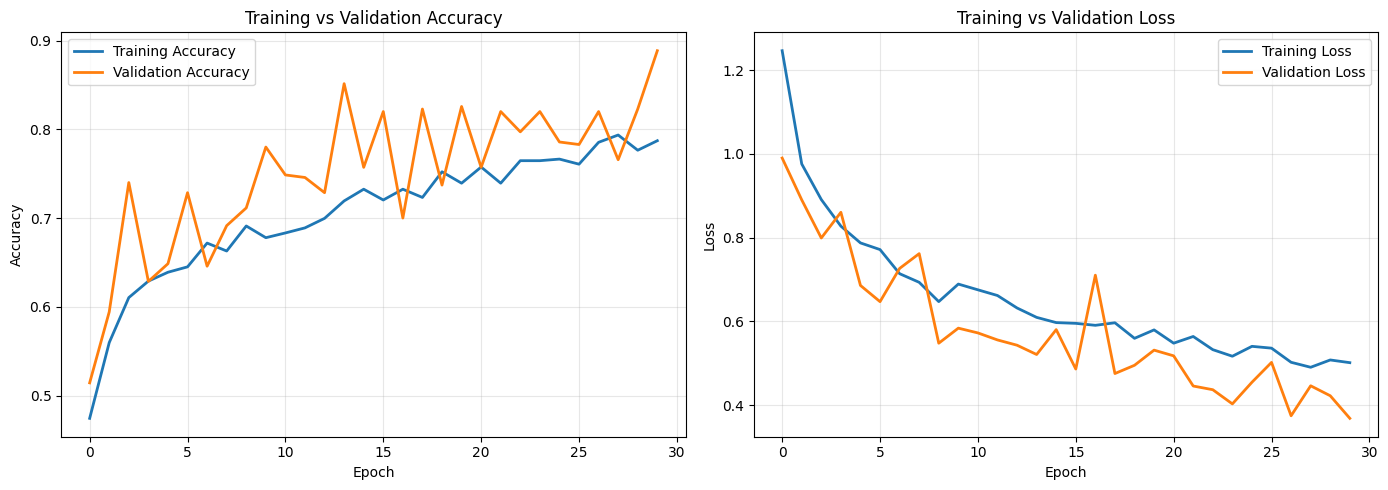

In [15]:
# Block 11: Plot the training and validation curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Meaning of Block 11: Visualizes the history dictionary that Block 10 built up epoch by epoch. In a healthy training run, both accuracy curves should rise together and both loss curves should fall together, staying reasonably close to each other. If training accuracy keeps climbing while validation accuracy flattens or drops — or if validation loss starts rising while training loss keeps falling — that's the visual signature of overfitting, and would be a signal to reconsider (more augmentation, stronger dropout, or fewer epochs), even though early stopping is already guarding against the worst of it.

In [16]:
# Block 12: Load the best saved checkpoint and evaluate on the held-out test set
cnn_model.load_state_dict(torch.load('best_tablet_defect_model.pt', map_location=DEVICE))
cnn_model.eval()
print("Best checkpoint loaded.")

test_loss, test_acc = evaluate(cnn_model, test_loader, criterion, DEVICE)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Best checkpoint loaded.

Test Loss: 0.3955
Test Accuracy: 0.8600 (86.00%)


Meaning of Block 12: Even though early_stopping already restores the best weights in memory, this explicitly reloads the checkpoint saved to disk in Block 10 — a safety measure ensuring you're evaluating the actual best-performing version, not whatever happened to be in memory if the notebook was interrupted or resumed later. The test set (350 images) has never been touched during training or the epoch-by-epoch validation checks — this is the first and only time the model is judged against it, making this the most trustworthy accuracy number in the whole notebook.

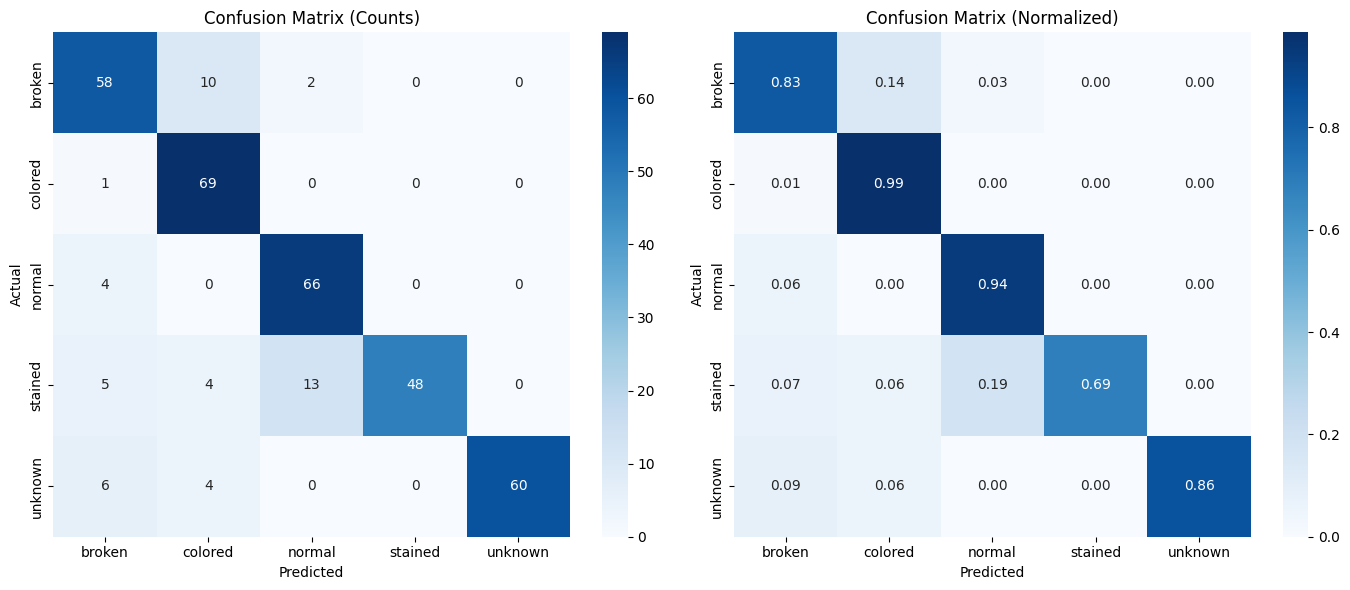

In [17]:
# Block 13: Generate predictions on the test set and build the confusion matrix
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = get_predictions(cnn_model, test_loader, DEVICE)
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}
target_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

Meaning of Block 13: A single test accuracy number hides which defects the model confuses with each other — the confusion matrix reveals that directly. Each row is the true defect type; each column is what the model predicted; the diagonal is correct predictions. The raw-count version (left) shows exact numbers; the normalized version (right, each row summing to 1.0) makes per-class error rates easier to compare even though each class has the same 70 test images here. Most important cell to check: how many normal tablets get misclassified as a defect (a false alarm — costly but safe) versus how many defective tablets get misclassified as normal (a missed defect — the more serious quality-control failure) — that second number matters more than overall accuracy in a real manufacturing context.

In [18]:
# Block 14: Full classification report and final training summary
print(classification_report(y_true, y_pred, target_names=target_names))

f1 = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')

print("="*55)
print("FINAL MODEL SUMMARY")
print("="*55)
print(f"Test Accuracy:      {test_acc*100:.2f}%")
print(f"Weighted F1-Score:  {f1*100:.2f}%")
print(f"Weighted Precision: {precision*100:.2f}%")
print(f"Weighted Recall:    {recall*100:.2f}%")
print(f"Total parameters:   {total_params:,}")

              precision    recall  f1-score   support

      broken       0.78      0.83      0.81        70
     colored       0.79      0.99      0.88        70
      normal       0.81      0.94      0.87        70
     stained       1.00      0.69      0.81        70
     unknown       1.00      0.86      0.92        70

    accuracy                           0.86       350
   macro avg       0.88      0.86      0.86       350
weighted avg       0.88      0.86      0.86       350

FINAL MODEL SUMMARY
Test Accuracy:      86.00%
Weighted F1-Score:  85.91%
Weighted Precision: 87.83%
Weighted Recall:    86.00%
Total parameters:   102,277


Meaning of Block 14: classification_report breaks precision, recall, and F1-score down per defect class — so you can see, for example, if stained tablets are harder to detect than broken ones, rather than only seeing one blended number. Precision answers "when the model says X, how often is it right?"; recall answers "of all the true X tablets, how many did it actually catch?" — both matter differently depending on which error type is more costly for a given defect. The weighted averages account for the fact that all 5 classes have equal test counts (70 each) here, so weighted and unweighted averages should be nearly identical — a good consistency check.

In [22]:
# Block 15: Save the final model and class mapping for deployment
torch.save(cnn_model.state_dict(), 'tablet_defect_final_model.pt')

import json
with open('class_mapping.json', 'w') as f:
    json.dump(idx_to_class, f)

from google.colab import files
files.download('tablet_defect_final_model.pt')
files.download('class_mapping.json')

print("Model and class mapping saved and downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model and class mapping saved and downloaded.


Meaning of Block 15: Saves the trained weights and, separately, the idx_to_class mapping (which numeric output corresponds to which defect name) as its own file — required together, since a saved model on its own only outputs numbers like 2, with no built-in memory of which number means normal versus stained.

Saving images (1).jpg to images (1).jpg


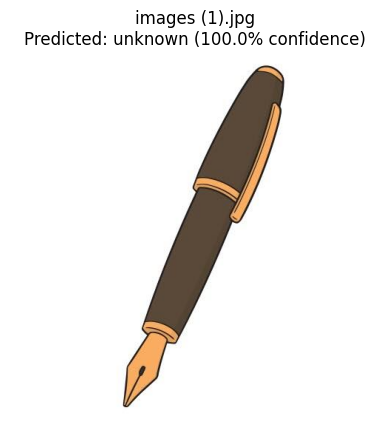


images (1).jpg
  broken: 0.00%
  colored: 0.00%
  normal: 0.00%
  stained: 0.00%
  unknown: 100.00%


In [23]:
# Block 16 (FINAL STAGE): Upload unknown tablet images and get a live defect prediction
from google.colab import files

# If starting a fresh session without earlier blocks already run, reload model + labels instead:
# cnn_model = TabletDefectCNN(num_classes=5).to(DEVICE)
# cnn_model.load_state_dict(torch.load('tablet_defect_final_model.pt', map_location=DEVICE))
# import json
# idx_to_class = json.load(open('class_mapping.json'))
# idx_to_class = {int(k): v for k, v in idx_to_class.items()}

cnn_model.eval()

uploaded = files.upload()   # select one or more tablet images (.jpg/.png) to check

predict_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for fname in uploaded.keys():
    img = Image.open(fname).convert('RGB')
    img_tensor = predict_transform(img).unsqueeze(0).to(DEVICE)   # add batch dimension

    with torch.no_grad():
        outputs = cnn_model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    predicted_idx = np.argmax(probs)
    predicted_class = idx_to_class[predicted_idx]
    confidence = probs[predicted_idx] * 100

    plt.figure()
    plt.imshow(img)
    plt.title(f"{fname}\nPredicted: {predicted_class} ({confidence:.1f}% confidence)")
    plt.axis("off")
    plt.show()

    print(f"\n{fname}")
    for i in range(NUM_CLASSES):
        print(f"  {idx_to_class[i]}: {probs[i]*100:.2f}%")